# Baseline XGBoost Model — Weekly Fantasy Points (PPR)

Trains an `XGBRegressor` on the Gold DataFrame produced by `ingestion/feature_building.ipynb` to predict the current week's `fantasy_points_ppr`.

**Approach**
- Time-based train/test split (train on weeks 1–10, test on weeks 11+) to simulate walk-forward validation — never a shuffled split on time-series data.
- Only pre-game information is used as features: shifted rolling averages, Vegas lines, weather, depth chart rank, injury flags, and opponent season-to-date rates. Same-week raw stats are explicitly dropped (they would leak the answer).
- Evaluation: overall MAE plus position-specific MAE (QB / RB / WR / TE), and top-10 feature importances.

In [1]:
# Install modeling dependencies (pandas/numpy come with the feature notebook)
%pip install xgboost scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /private/tmp/ffe_venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Load the Gold DataFrame

`gold_df` is produced by the feature engineering notebook. In Databricks, uncomment the `%run` line below; in local Jupyter, run `ingestion/feature_building.ipynb` in this kernel first.

In [2]:
import pandas as pd
import numpy as np

# In Databricks, produce gold_df by running the feature engineering notebook:
# %run ../ingestion/feature_building

# Standalone fallback: load the Gold table saved by the feature notebook
if 'gold_df' not in globals():
    gold_df = pd.read_parquet('../data/gold_df.parquet')

print(f"gold_df: {gold_df.shape[0]:,} rows x {gold_df.shape[1]} columns")
print(f"Weeks: {gold_df['week'].min()} - {gold_df['week'].max()}")
print(f"Positions: {gold_df['position'].value_counts().to_dict()}")

gold_df: 14,470 rows x 69 columns
Weeks: 1 - 22
Positions: {'WR': 6836, 'RB': 4469, 'TE': 1641, 'QB': 1524}


## Step 1: Data Preprocessing

Three things happen here:

1. **Drop identifiers** (`player_id`, `player_name`, `recent_team`, …) — non-predictive strings. `position` and `week` are kept.
2. **Drop same-week outcome columns.** The Gold table still carries the current week's raw stats (receptions, yards, TDs, snap share, target share, WOPR, …) because they were needed to *build* the shifted features. They are outcomes of the game being predicted — receptions literally determine PPR points — so keeping them would leak the answer and produce a uselessly optimistic MAE. Only pre-game information survives this step.
3. **One-hot encode `position`** and fill remaining NaNs with 0.

In [3]:
# ============================================================================
# STEP 1: DATA PREPROCESSING
# ============================================================================

# Keep identifying info aside for post-hoc evaluation (index stays aligned
# with the modeling frame because nothing is shuffled or re-indexed).
eval_meta = gold_df[['player_id', 'player_name', 'recent_team', 'position', 'week']].copy()

df = gold_df.copy()

# --- 1a. Drop non-predictive identifier columns (keep position + week) ---
identifier_cols = [
    'player_id', 'player_name', 'recent_team',   # player identity
    'opponent', 'starting_qb_id',                # string ids already encoded via matchup features
    'gameday',                                   # datetime; week carries the time signal
]
df = df.drop(columns=[c for c in identifier_cols if c in df.columns])

# --- 1b. Drop SAME-WEEK outcome columns (leakage guard) ---
# These are raw stats from the week being predicted. They were only kept in
# gold_df as intermediates for building the shifted rolling features.
same_week_outcome_cols = [
    # passing box score
    'pass_attempts', 'completions', 'passing_yards', 'passing_tds', 'interceptions',
    # rushing box score
    'rush_attempts', 'rushing_yards', 'rushing_tds',
    # receiving box score
    'targets', 'receptions', 'receiving_yards', 'receiving_tds',
    # same-week usage intermediates
    'player_opportunities', 'team_total_opportunities', 'opportunity_share',
    'hvt_carries', 'hvt_targets', 'total_hvts',
    'team_pass_attempts', 'target_share',
    'player_air_yards', 'team_air_yards', 'air_yards_share',
    'wopr', 'snap_share',
]
df = df.drop(columns=[c for c in same_week_outcome_cols if c in df.columns])

# --- 1c. One-hot encode position so the model can distinguish QB/RB/WR/TE ---
df = pd.get_dummies(df, columns=['position'], prefix='pos')

# --- 1d. Explicit NaN handling (XGBoost tolerates NaN, but explicit is safer) ---
df = df.fillna(0)

# Safety net: anything non-numeric that slipped through cannot go to XGBoost
non_numeric = df.select_dtypes(exclude=['number', 'bool']).columns.tolist()
if non_numeric:
    print(f"Dropping unexpected non-numeric columns: {non_numeric}")
    df = df.drop(columns=non_numeric)

print(f"Modeling dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Feature columns:\n{sorted(c for c in df.columns if c != 'fantasy_points_ppr')}")

Modeling dataset: 14,470 rows x 41 columns
Feature columns:
['depth_chart_rank', 'fantasy_points_3wk_avg', 'fantasy_points_5wk_avg', 'implied_total', 'is_bad_weather', 'is_dome', 'is_home', 'opp_def_ppg_allowed', 'opp_def_sack_rate', 'opp_def_ypc_allowed', 'opp_def_ypp_allowed', 'pos_QB', 'pos_RB', 'pos_TE', 'pos_WR', 'qb_pass_attempts_3wk_avg', 'qb_pass_attempts_5wk_avg', 'qb_rushing_yards_3wk_avg', 'qb_rushing_yards_5wk_avg', 'rb_hvts_3wk_avg', 'rb_hvts_5wk_avg', 'rb_opportunity_share_3wk_avg', 'rb_opportunity_share_5wk_avg', 'rb_snap_share_3wk_avg', 'rb_snap_share_5wk_avg', 'rest_advantage', 'season', 'starting_qb_aya', 'team_sack_rate_allowed', 'team_spread', 'temp', 'week', 'wind', 'wr1_wr2_healthy', 'wr_te_air_yards_share_3wk_avg', 'wr_te_air_yards_share_5wk_avg', 'wr_te_target_share_3wk_avg', 'wr_te_target_share_5wk_avg', 'wr_te_wopr_3wk_avg', 'wr_te_wopr_5wk_avg']


## Step 2: Time-Based Train/Test Split

Train on all completed prior seasons plus weeks 1–10 of the latest season; test on weeks 11+ of the latest season. No shuffling — a random split would let the model train on games played *after* the ones it is tested on, which invalidates the evaluation for time-series data.

In [4]:
# ============================================================================
# STEP 2: TIME-BASED TRAIN/TEST SPLIT (walk-forward simulation)
# ============================================================================

TARGET = 'fantasy_points_ppr'
TRAIN_MAX_WEEK = 10

# With multiple seasons in gold_df, test only on the most recent season.
# All earlier seasons are entirely in the past, so they belong to training.
TEST_SEASON = df['season'].max()

train_mask = (df['season'] < TEST_SEASON) | (
    (df['season'] == TEST_SEASON) & (df['week'] <= TRAIN_MAX_WEEK)
)
test_mask = (df['season'] == TEST_SEASON) & (df['week'] > TRAIN_MAX_WEEK)

feature_cols = [c for c in df.columns if c != TARGET]

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, TARGET]
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, TARGET]

print(f"Train: seasons < {TEST_SEASON} + weeks 1-{TRAIN_MAX_WEEK} of {TEST_SEASON} -> {len(X_train):,} rows")
print(f"Test:  weeks {TRAIN_MAX_WEEK + 1}+ of {TEST_SEASON} -> {len(X_test):,} rows")
print(f"Features: {len(feature_cols)}")

Train: seasons < 2025 + weeks 1-10 of 2025 -> 12,171 rows
Test:  weeks 11+ of 2025 -> 2,299 rows
Features: 40


## Step 3: Model Training

Baseline `XGBRegressor` with sensible defaults — no tuning yet. `random_state` is fixed for reproducibility.

In [5]:
# ============================================================================
# STEP 3: MODEL TRAINING
# ============================================================================
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,      # number of boosting rounds
    learning_rate=0.1,     # shrinkage per round
    max_depth=4,           # shallow trees generalize better on noisy weekly data
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 4: Prediction and Evaluation

Overall MAE, then MAE broken out by position by re-attaching predictions to the identifying columns saved in Step 1.

In [6]:
# ============================================================================
# STEP 4: PREDICTION AND EVALUATION
# ============================================================================
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

# --- Overall MAE ---
overall_mae = mean_absolute_error(y_test, predictions)
print("=" * 60)
print(f"OVERALL TEST MAE: {overall_mae:.2f} fantasy points")
print("=" * 60)

# --- Re-attach predictions to identity columns for position-level analysis ---
# eval_meta was saved before preprocessing; row indices are still aligned.
results = eval_meta.loc[X_test.index].copy()
results['actual_ppr'] = y_test.values
results['predicted_ppr'] = predictions
results['abs_error'] = (results['actual_ppr'] - results['predicted_ppr']).abs()

# --- Position-specific MAE ---
position_mae = (
    results.groupby('position')
    .agg(mae=('abs_error', 'mean'), n_player_weeks=('abs_error', 'size'))
    .reindex(['QB', 'RB', 'WR', 'TE'])
    .round(2)
)
print("\nMAE BY POSITION:")
print(position_mae.to_string())

# --- Sanity check: naive baseline (predict every player's 3-week average) ---
# The model must beat this to justify its existence.
naive_mae = mean_absolute_error(
    y_test, df.loc[X_test.index, 'fantasy_points_3wk_avg']
)
print(f"\nNaive baseline (predict 3wk avg): MAE = {naive_mae:.2f}")
print(f"Model improvement over naive:     {naive_mae - overall_mae:+.2f} points")

# --- Best and worst predictions for inspection ---
print("\nSample predictions (test set):")
display(
    results.sort_values('actual_ppr', ascending=False)
    [['week', 'player_name', 'position', 'actual_ppr', 'predicted_ppr', 'abs_error']]
    .head(10)
    .round(2)
)

OVERALL TEST MAE: 4.87 fantasy points

MAE BY POSITION:
           mae  n_player_weeks
position                      
QB        6.21             250
RB        4.70             711
WR        4.62            1087
TE        5.08             251

Naive baseline (predict 3wk avg): MAE = 5.35
Model improvement over naive:     +0.48 points

Sample predictions (test set):


,week,player_name,position,actual_ppr,predicted_ppr,abs_error
12232,12,J.Gibbs,RB,55.400002,25.600000,29.799999
12176,16,P.Nacua,WR,46.500000,15.910000,30.590000
1412,17,D.Henry,RB,45.599998,12.760000,32.840000
7885,15,K.Pitts,TE,45.599998,13.470000,32.130001
7928,15,T.Lawrence,QB,44.299999,20.250000,24.049999
4087,11,J.Allen,QB,42.680000,20.170000,22.510000
7834,15,A.St. Brown,WR,42.200001,12.940000,29.260000
10522,17,B.Robinson,RB,39.900002,16.709999,23.190001
9501,15,T.McBride,TE,37.400002,14.770000,22.629999
10738,14,M.Wilson,WR,37.200001,11.880000,25.320000


## Step 5: Feature Importance

Top 10 features by XGBoost importance — this shows which business rules the model found most predictive.

Matplotlib is building the font cache; this may take a moment.


TOP 10 MOST IMPORTANT FEATURES:
                    feature  importance
0    fantasy_points_5wk_avg      0.3251
1          depth_chart_rank      0.0817
2                    pos_QB      0.0661
3                    pos_TE      0.0365
4        wr_te_wopr_5wk_avg      0.0356
5    fantasy_points_3wk_avg      0.0356
6  qb_rushing_yards_5wk_avg      0.0268
7             implied_total      0.0231
8     rb_snap_share_3wk_avg      0.0221
9                      week      0.0217


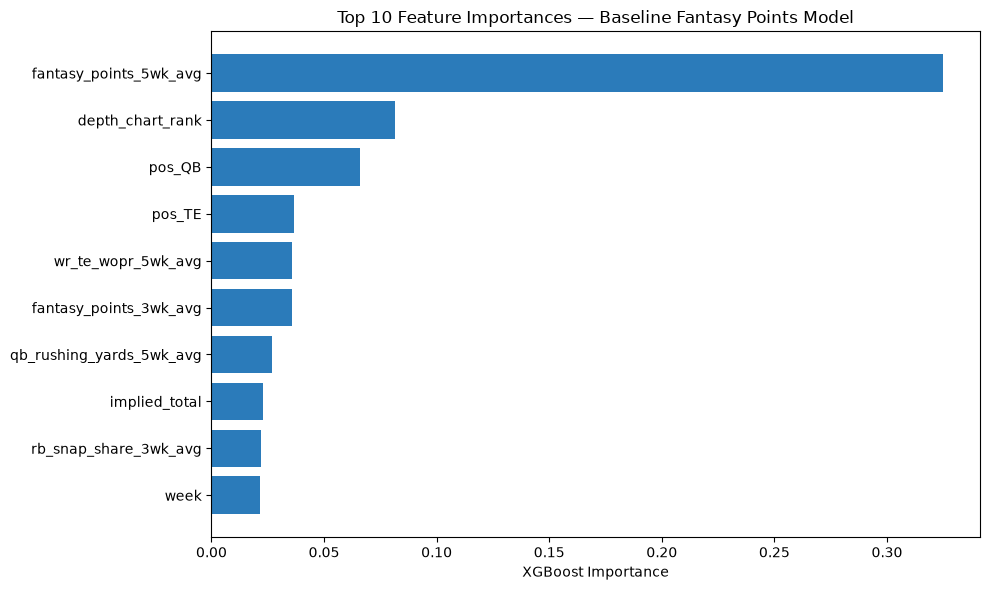

In [7]:
# ============================================================================
# STEP 5: FEATURE IMPORTANCE
# ============================================================================
import matplotlib.pyplot as plt

importance = (
    pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("TOP 10 MOST IMPORTANT FEATURES:")
print(importance.head(10).round(4).to_string())

# Horizontal bar chart, most important on top
top10 = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['feature'], top10['importance'], color='#2b7bba')
ax.set_xlabel('XGBoost Importance')
ax.set_title('Top 10 Feature Importances — Baseline Fantasy Points Model')
plt.tight_layout()
plt.show()